# Sustainability-Aware Asset Management

## Minimum-Variance Portfolio with Carbon Emission Reduction — AMER Region

> **Course:** Sustainability Aware Asset Management — MScF Finance, HEC Lausanne  
> **Professor:** Eric Jondeau  
> **Region:** Americas (**AMER**)  
> **Scope:** **Scope 1**  
> **Period:** Out-of-sample **2014–2025** (estimation window **2004–2013**, rolling)  
> **Group:** **Group A** — Nadim MOUSSLIE, Leonard PERIGAULT, Mattia COMISETI, Matteo GIRAUD

## Execution Order

```text
src/
├── main.py                       # Entry point — runs the full pipeline
│
├── data_loader.py                # 1. Load all Datastream Excel files
│
├── data_cleaning.py              # 2. Clean prices, returns, CO2, revenue and market cap data
│
├── investment_set.py             # 3. Build yearly eligible investment sets
│
├── optimization.py               # 4. Compute minimum-variance portfolio weights
│
├── portfolio_returns.py          # 5. Compute MV and VW monthly portfolio returns
│
├── performance.py                # 6. Compute performance statistics and Part I plots
│
├── carbon.py                     # 7. Compute CI, WACI and CF carbon metrics
│
├── carbon_portfolio.py           # 8. Build carbon-constrained and net-zero portfolios
│
└── comparison.py                 # 9. Compare portfolios and generate final plots
```

## Pipeline Overview

```text
load_all()
    └─► clean_all()
            └─► build_investment_sets()
                    └─► run_optimization()          # Part I
                            └─► compute_all_returns()
                                    └─► run_performance()
                                            └─► compute_carbon_intensity()   # Part II
                                                    └─► run_mv_carbon()      # Section 3.2
                                                    └─► run_te_carbon()      # Section 3.3
                                                    └─► run_net_zero()       # Section 4.1
                                                    └─► compare_portfolios() # 3.4 & 4.2

# config.py

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data/raw')

PATHS = {
    "ri_monthly" : DATA_DIR / "DS_RI_T_USD_M_2025.xlsx",
    "ri_yearly"  : DATA_DIR / "DS_RI_T_USD_Y_2025.xlsx",
    "mv_monthly" : DATA_DIR / "DS_MV_T_USD_M_2025.xlsx",
    "mv_yearly"  : DATA_DIR / "DS_MV_T_USD_Y_2025.xlsx",
    "co2"        : DATA_DIR / "DS_CO2_SCOPE_1_Y_2025.xlsx",
    "static"     : DATA_DIR / "Static_2025.xlsx",
    "risk_free"  : DATA_DIR / "Risk_Free_Rate_2025.xlsx",
    "revenue"    : DATA_DIR / "DS_REV_Y_2025.xlsx",
}

REGION = "AMER"
ESTIMATION_YEARS = 10
TAU = ESTIMATION_YEARS * 12
REBALANCE_YEARS = list(range(2013, 2025))
LOW_PRICE_THRESHOLD = 0.5
STALE_THRESHOLD = 0.50
MIN_MONTHS_DATA = 36


# data_loader.py

In [2]:
def _load_ds_wide(path, sheet, sheet_candidates=None):
    workbook = pd.ExcelFile(path)
    candidates = [sheet, *(sheet_candidates or [])]
    selected_sheet = next(
        (c for c in candidates if c in workbook.sheet_names),
        workbook.sheet_names[0],
    )
    df = pd.read_excel(workbook, sheet_name=selected_sheet, index_col=None)
    df = df[df["ISIN"].notna()].copy()
    df = df[~df["ISIN"].astype(str).str.startswith("$$")].copy()
    df = df.drop(columns=["NAME"], errors="ignore")
    df = df.set_index("ISIN")
    new_cols = []
    for c in df.columns:
        if isinstance(c, pd.Timestamp):
            new_cols.append(c)
        else:
            try:
                year = int(float(str(c)))
                new_cols.append(pd.Timestamp(f"{year}-12-31"))
            except Exception:
                new_cols.append(c)
    df.columns = new_cols
    df = df[[c for c in df.columns if isinstance(c, pd.Timestamp)]]
    return df


def load_all(region=REGION):
    print("=" * 55)
    print("LOADING DATA")
    print("=" * 55)
    static = pd.read_excel(PATHS["static"]).set_index("ISIN")
    amer_isins = static[static["Region"] == region].index.tolist()
    print(f"  Region '{region}' -> {len(amer_isins)} firms")

    ri_m = _load_ds_wide(PATHS["ri_monthly"], sheet="RI")
    ri_m = ri_m[ri_m.index.isin(amer_isins)]
    ri_m = ri_m.apply(pd.to_numeric, errors="coerce")
    print(f"  RI monthly  : {ri_m.shape[0]} firms x {ri_m.shape[1]} months")

    ri_y = _load_ds_wide(PATHS["ri_yearly"], sheet="RI")
    ri_y = ri_y[ri_y.index.isin(amer_isins)]
    ri_y = ri_y.apply(pd.to_numeric, errors="coerce")
    print(f"  RI yearly   : {ri_y.shape[0]} firms x {ri_y.shape[1]} years")

    mv_m = _load_ds_wide(PATHS["mv_monthly"], sheet="MV")
    mv_m = mv_m[mv_m.index.isin(amer_isins)]
    mv_m = mv_m.apply(pd.to_numeric, errors="coerce")
    print(f"  MV monthly  : {mv_m.shape[0]} firms x {mv_m.shape[1]} months")

    mv_y = _load_ds_wide(PATHS["mv_yearly"], sheet="MV")
    mv_y = mv_y[mv_y.index.isin(amer_isins)]
    mv_y = mv_y.apply(pd.to_numeric, errors="coerce")
    print(f"  MV yearly   : {mv_y.shape[0]} firms x {mv_y.shape[1]} years")

    co2 = _load_ds_wide(PATHS["co2"], sheet="Scope1", sheet_candidates=["SCOPE1"])
    co2 = co2[co2.index.isin(amer_isins)]
    co2 = co2.apply(pd.to_numeric, errors="coerce")
    print(f"  CO2 Scope-1 : {co2.shape[0]} firms x {co2.shape[1]} years")

    revenue = _load_ds_wide(
        PATHS["revenue"], sheet="Revenue",
        sheet_candidates=["REV", "Revenues", "Revenue USD"],
    )
    revenue = revenue[revenue.index.isin(amer_isins)]
    revenue = revenue.apply(pd.to_numeric, errors="coerce")
    print(f"  Revenue     : {revenue.shape[0]} firms x {revenue.shape[1]} years")

    rf_raw = pd.read_excel(PATHS["risk_free"])
    rf_raw.columns = ["date", "RF"]
    rf_raw["date"] = pd.to_datetime(rf_raw["date"].astype(str), format="%Y%m")
    rf_raw["date"] = rf_raw["date"] + pd.offsets.MonthEnd(0)
    rf = rf_raw.set_index("date")["RF"] / 100
    print(f"  Risk-free   : {rf.index[0].date()} -> {rf.index[-1].date()}")
    print("  All files loaded.\n")

    return {
        "ri_m": ri_m, "ri_y": ri_y, "mv_m": mv_m, "mv_y": mv_y,
        "co2": co2, "revenue": revenue, "rf": rf, "static": static,
        "amer_isins": amer_isins,
    }

# data_cleaning.py

In [3]:
def _fill_internal_gaps(df):
    ffilled = df.T.ffill().T
    has_future_obs = df.notna().iloc[:, ::-1].cummax(axis=1).iloc[:, ::-1]
    fill_mask = df.isna() & has_future_obs
    return df.where(~fill_mask, ffilled)


def _forward_fill_annual(df):
    filled = df.T.ffill().T
    n_filled = df.isna().sum().sum() - filled.isna().sum().sum()
    return filled, n_filled


def is_stale(return_series, threshold=STALE_THRESHOLD):
    valid = return_series.dropna()
    if len(valid) == 0:
        return True
    return (valid == 0).mean() > threshold


def clean_all(data):
    print("=" * 55)
    print("DATA CLEANING")
    print("=" * 55)
    ri_m = data["ri_m"].copy()
    before = ri_m.shape[0]
    valid_isins = ri_m.dropna(how="all").index
    after = len(valid_isins)
    print(f"  [1] Drop all-NaN ISINs   : {before} -> {after} firms ({before - after} removed)")
    for key in ("ri_m", "ri_y", "mv_m", "mv_y", "co2", "revenue", "static"):
        value = data.get(key)
        if isinstance(value, pd.DataFrame):
            data[key] = value.reindex(valid_isins)
    if "amer_isins" in data:
        data["amer_isins"] = [i for i in data["amer_isins"] if i in valid_isins]
    ri_m = data["ri_m"].copy()
    ri_y = data["ri_y"].copy()
    co2 = data["co2"].copy()
    revenue = data.get("revenue")
    if isinstance(revenue, pd.DataFrame):
        revenue = revenue.copy()
    n_low_m = (ri_m < LOW_PRICE_THRESHOLD).sum().sum()
    n_low_y = (ri_y < LOW_PRICE_THRESHOLD).sum().sum()
    ri_m[ri_m < LOW_PRICE_THRESHOLD] = np.nan
    ri_y[ri_y < LOW_PRICE_THRESHOLD] = np.nan
    print(f"  [2] Low prices -> NaN     : {n_low_m} cells in monthly, {n_low_y} in yearly")
    ri_m_filled = _fill_internal_gaps(ri_m)
    ri_y_filled = _fill_internal_gaps(ri_y)
    filled_m = ri_m.isna().sum().sum() - ri_m_filled.isna().sum().sum()
    filled_y = ri_y.isna().sum().sum() - ri_y_filled.isna().sum().sum()
    print(f"  [3] Forward-fill         : {filled_m} cells filled in monthly, {filled_y} in yearly")
    ri_m = ri_m_filled
    ri_y = ri_y_filled
    co2, filled_co2 = _forward_fill_annual(co2)
    print(f"  [4] CO2 forward-fill     : {filled_co2} yearly cells filled")
    if revenue is not None:
        revenue, filled_rev = _forward_fill_annual(revenue)
        print(f"  [5] Revenue forward-fill : {filled_rev} yearly cells filled")
    returns_m = ri_m.pct_change(axis=1, fill_method=None)
    delist_mask = ri_m.isna() & ri_m.shift(1, axis=1).notna()
    returns_m = returns_m.mask(delist_mask, -1.0)
    print(f"  Final RI monthly : {ri_m.shape[0]} firms x {ri_m.shape[1]} months")
    print(f"  Final returns_m  : {returns_m.shape[0]} firms x {returns_m.shape[1]} months")
    print("  Cleaning done.\n")
    data["ri_m"] = ri_m
    data["ri_y"] = ri_y
    data["co2"] = co2
    if revenue is not None:
        data["revenue"] = revenue
    data["returns_m"] = returns_m
    return data


# investment_set.py

In [4]:
def _get_dec_col(df, year):
    cols = pd.DatetimeIndex(df.columns)
    dec_cols = cols[(cols.year == year) & (cols.month == 12)]
    return dec_cols[-1] if len(dec_cols) > 0 else None


def build_investment_sets(data):
    print("=" * 55)
    print("BUILDING INVESTMENT SETS")
    print("=" * 55)
    returns_m = data["returns_m"]
    ri_m = data["ri_m"]
    co2 = data["co2"]
    invest_sets = {}
    ret_windows = {}
    for Y in REBALANCE_YEARS:
        dec_Y = _get_dec_col(returns_m, Y)
        if dec_Y is None:
            continue
        all_cols = pd.DatetimeIndex(returns_m.columns)
        window_cols = all_cols[all_cols <= dec_Y][-TAU:]
        ret_window = returns_m[window_cols]
        co2_dec = _get_dec_col(co2, Y)
        if co2_dec is not None:
            has_co2 = co2[co2_dec].notna()
        else:
            has_co2 = pd.Series(False, index=co2.index)
        ri_dec = _get_dec_col(ri_m, Y)
        if ri_dec is not None:
            has_price = ri_m[ri_dec].notna()
        else:
            has_price = pd.Series(False, index=ri_m.index)
        n_valid = ret_window.notna().sum(axis=1)
        enough_data = n_valid >= MIN_MONTHS_DATA
        not_stale = ret_window.apply(lambda row: not is_stale(row), axis=1)
        eligible = (
            has_co2.reindex(ret_window.index, fill_value=False)
            & has_price.reindex(ret_window.index, fill_value=False)
            & enough_data
            & not_stale
        )
        isins_Y = eligible[eligible].index.tolist()
        invest_sets[Y] = isins_Y
        ret_windows[Y] = ret_window
        print(f"  {Y}: {len(isins_Y):>4} eligible firms "
              f"(window: {window_cols[0].date()} -> {window_cols[-1].date()})")
    print(f"  Investment sets built for {len(invest_sets)} years.\n")
    return invest_sets, ret_windows


# optimization.py

In [5]:
def _covariance_matrix(ret):
    sigma = ret.T.cov(min_periods=MIN_MONTHS_DATA, ddof=0)
    valid = sigma.notna().all(axis=1)
    sigma = sigma.loc[valid, valid]
    return sigma


def _min_variance_weights(cov):
    n = cov.shape[0]
    w0 = np.ones(n) / n
    result = minimize(
        fun=lambda w, S=cov: w @ S @ w,
        x0=w0,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
        options={"ftol": 1e-9, "maxiter": 500},
    )
    if not result.success:
        print(f"    WARNING: MV solver did not converge - {result.message}")
    return result.x if result.success else w0


def run_optimization(invest_sets, ret_windows):
    print("=" * 55)
    print("MINIMUM-VARIANCE OPTIMIZATION")
    print("=" * 55)
    weights_dict = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets:
            continue
        isins_Y = invest_sets[Y]
        if len(isins_Y) < 2:
            continue
        ret_window = ret_windows[Y].loc[isins_Y]
        sigma_df = _covariance_matrix(ret_window)
        if sigma_df.shape[0] < 2:
            continue
        kept = sigma_df.index.tolist()
        Sigma = sigma_df.values
        w = _min_variance_weights(Sigma)
        weights_dict[Y] = pd.Series(w, index=kept)
        port_var = w @ Sigma @ w
        print(f"  {Y}: {len(kept):>4} firms | "
              f"port. variance = {port_var:.6f} | "
              f"ann. vol = {np.sqrt(port_var * 12) * 100:.2f}%")
    print(f"  Optimization done for {len(weights_dict)} years.\n")
    return weights_dict


# portfolio_returns.py

In [6]:
def compute_mv_returns(weights_dict, returns_m):
    all_cols = pd.DatetimeIndex(returns_m.columns)
    mv_returns = {}
    for Y in REBALANCE_YEARS:
        if Y not in weights_dict:
            continue
        w0 = weights_dict[Y]
        isins_Y = w0.index.tolist()
        year_cols = all_cols[all_cols.year == Y + 1]
        if len(year_cols) == 0:
            continue
        firms_in_data = [i for i in isins_Y if i in returns_m.index]
        ret_year = (
            returns_m.loc[firms_in_data, year_cols]
            .reindex(index=isins_Y)
            .fillna(0)
        )
        alpha = w0.values.copy()
        for col in year_cols:
            r_vec = ret_year[col].values
            r_p = float(alpha @ r_vec)
            mv_returns[col] = r_p
            denom = 1 + r_p
            if abs(denom) > 1e-10:
                alpha = alpha * (1 + r_vec) / denom
    mv_series = pd.Series(mv_returns).sort_index()
    print(f"  MV : {len(mv_series)} months  "
          f"({mv_series.index[0].date()} -> {mv_series.index[-1].date()})")
    return mv_series


def compute_vw_returns(invest_sets, returns_m, mv_m):
    all_cols_ret = pd.DatetimeIndex(returns_m.columns)
    all_cols_mv = pd.DatetimeIndex(mv_m.columns)
    vw_returns = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets:
            continue
        isins_Y = invest_sets[Y]
        year_cols = all_cols_ret[all_cols_ret.year == Y + 1]
        if len(year_cols) == 0:
            continue
        for col in year_cols:
            prev_month = col - pd.offsets.MonthEnd(1)
            mv_cols_avail = all_cols_mv[all_cols_mv <= prev_month]
            if len(mv_cols_avail) == 0:
                continue
            mv_col = mv_cols_avail[-1]
            firms_in_mv = [i for i in isins_Y if i in mv_m.index]
            caps = mv_m.loc[firms_in_mv, mv_col].dropna()
            if caps.sum() == 0 or len(caps) == 0:
                continue
            w_vw = caps / caps.sum()
            firms_in_ret = [i for i in w_vw.index if i in returns_m.index]
            ret_col = returns_m.loc[firms_in_ret, col].fillna(0)
            r_vw = (w_vw.reindex(ret_col.index).fillna(0) * ret_col).sum()
            vw_returns[col] = r_vw
    vw_series = pd.Series(vw_returns).sort_index()
    print(f"  VW : {len(vw_series)} months  "
          f"({vw_series.index[0].date()} -> {vw_series.index[-1].date()})")
    return vw_series


def compute_all_returns(weights_dict, invest_sets, data):
    mv_series = compute_mv_returns(weights_dict, data["returns_m"])
    vw_series = compute_vw_returns(invest_sets, data["returns_m"], data["mv_m"])
    return mv_series, vw_series


# performance.py

In [7]:
def compute_stats(ret, rf, label):
    rf_aligned = rf.reindex(ret.index).fillna(0)
    excess = ret - rf_aligned
    mu_ann = ret.mean() * 12
    sigma_ann = ret.std() * np.sqrt(12)
    sr = excess.mean() / ret.std() * np.sqrt(12) if ret.std() > 0 else np.nan
    return {
        "label": label, "mu_p": mu_ann, "sigma_p": sigma_ann,
        "SR_p": sr, "min": ret.min(), "max": ret.max(), "n_obs": len(ret),
    }


def print_stats_table(stats_mv, stats_vw):
    metrics = [
        ("Annualised avg return", "mu_p", "{:.2%}"),
        ("Annualised volatility", "sigma_p", "{:.2%}"),
        ("Sharpe ratio", "SR_p", "{:.4f}"),
        ("Min monthly return", "min", "{:.2%}"),
        ("Max monthly return", "max", "{:.2%}"),
        ("N observations", "n_obs", "{:d}"),
    ]
    col_w = 28
    print("=" * (col_w * 3))
    print("PERFORMANCE SUMMARY")
    print("=" * (col_w * 3))
    header = (f"\n{'Metric':<{col_w}}"
              f"{'Min-Variance':>{col_w}}"
              f"{'Value-Weighted':>{col_w}}")
    print(header)
    print("-" * (col_w * 3))
    for name, key, fmt in metrics:
        v_mv = fmt.format(stats_mv[key])
        v_vw = fmt.format(stats_vw[key])
        print(f"  {name:<{col_w - 2}}{v_mv:>{col_w}}{v_vw:>{col_w}}")
    print("=" * (col_w * 3) + "\n")


def build_monthly_table(mv_ret, vw_ret):
    common = mv_ret.index.union(vw_ret.index)
    df = pd.DataFrame({
        "MV_Return": mv_ret.reindex(common),
        "VW_Return": vw_ret.reindex(common),
    }, index=common)
    df.index.name = "Date"
    return df.sort_index()


def plot_cumulative_returns(mv_ret, vw_ret):
    common = mv_ret.index.intersection(vw_ret.index)
    cum_mv = (1 + mv_ret.loc[common]).cumprod()
    cum_vw = (1 + vw_ret.loc[common]).cumprod()
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(cum_mv.index, cum_mv.values,
            label="Min-Variance  $P^{mv}_{oos}$",
            linewidth=2.0, color="steelblue")
    ax.plot(cum_vw.index, cum_vw.values,
            label="Value-Weighted  $P^{vw}$",
            linewidth=2.0, color="darkorange", linestyle="--")
    ax.set_title("Cumulative Returns - AMER Region (2014-2025) - MV & VW",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Cumulative Return (base = 1)", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


def run_performance(mv_ret, vw_ret, rf):
    print("=" * 55)
    print("PERFORMANCE ANALYSIS")
    print("=" * 55)
    stats_mv = compute_stats(mv_ret, rf, "Min-Variance")
    stats_vw = compute_stats(vw_ret, rf, "Value-Weighted")
    print_stats_table(stats_mv, stats_vw)
    plot_cumulative_returns(mv_ret, vw_ret)
    monthly_df = build_monthly_table(mv_ret, vw_ret)
    display(monthly_df)
    

# carbon.py

In [8]:
def compute_carbon_intensity(co2, revenue):
    common_cols = co2.columns.intersection(revenue.columns)
    co2_a = co2[common_cols]
    rev_a = revenue[common_cols] / 1000
    ci = co2_a / rev_a
    ci = ci.replace([np.inf, -np.inf], np.nan)
    return ci


def compute_waci(weights, ci, year):
    cols = pd.DatetimeIndex(ci.columns)
    dec_cols = cols[(cols.year == year) & (cols.month == 12)]
    if len(dec_cols) == 0:
        return np.nan
    ci_year = ci[dec_cols[-1]]
    common = weights.index.intersection(ci_year.index)
    w = weights.reindex(common).fillna(0)
    c = ci_year.reindex(common)
    valid = c.notna()
    w_valid = w[valid]
    c_valid = c[valid]
    if w_valid.sum() == 0:
        return np.nan
    return float(w_valid @ c_valid)


def compute_cf(weights, co2, mv_y, year, portfolio_value=1.0):
    def _get_dec_cf(df):
        cols = pd.DatetimeIndex(df.columns)
        dec = cols[(cols.year == year) & (cols.month == 12)]
        return df[dec[-1]] if len(dec) > 0 else None
    co2_year = _get_dec_cf(co2)
    cap_year = _get_dec_cf(mv_y)
    if co2_year is None or cap_year is None:
        return np.nan
    common = weights.index.intersection(co2_year.index).intersection(cap_year.index)
    w = weights.reindex(common).fillna(0)
    e = co2_year.reindex(common)
    cap = cap_year.reindex(common)
    valid = e.notna() & cap.notna() & (cap > 0)
    w_v, e_v, cap_v = w[valid], e[valid], cap[valid]
    if w_v.sum() == 0:
        return np.nan
    return float((w_v / cap_v * e_v).sum())


def compute_portfolio_carbon_metrics(weights_dict, ci, co2, mv_y, label="Portfolio"):
    records = []
    for Y in REBALANCE_YEARS:
        if Y not in weights_dict:
            continue
        w = weights_dict[Y]
        waci = compute_waci(w, ci, Y)
        cf = compute_cf(w, co2, mv_y, Y)
        records.append({"Year": Y, "WACI": waci, "CF": cf})
    df = pd.DataFrame(records).set_index("Year")
    print(f"  {label} carbon metrics computed for {len(df)} years.")
    return df


def top_carbon_contributors(weights_dict, ci, static, year, top_n=10):
    if year not in weights_dict:
        return pd.DataFrame()
    cols = pd.DatetimeIndex(ci.columns)
    dec = cols[(cols.year == year) & (cols.month == 12)]
    if len(dec) == 0:
        return pd.DataFrame()
    w = weights_dict[year]
    ci_year = ci[dec[-1]]
    common = w.index.intersection(ci_year.index)
    contrib = (w.reindex(common).fillna(0) * ci_year.reindex(common)).dropna()
    contrib = contrib.sort_values(ascending=False).head(top_n)
    result = pd.DataFrame({
        "ISIN": contrib.index,
        "Contribution": contrib.values,
        "Weight": w.reindex(contrib.index).values,
        "CI": ci_year.reindex(contrib.index).values,
    })
    if "NAME" in static.columns:
        result["Name"] = static["NAME"].reindex(contrib.index).values
    elif static.index.name == "ISIN":
        result["Name"] = result["ISIN"]
    if "Name" in result.columns:
        result = result[["ISIN", "Name", "Weight", "CI", "Contribution"]]
    result = result.reset_index(drop=True)
    return result


def plot_carbon_metrics(metrics_mv, metrics_vw):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(metrics_mv.index, metrics_mv["WACI"],
                 marker="o", label="Min-Variance", color="steelblue", linewidth=2)
    axes[0].plot(metrics_vw.index, metrics_vw["WACI"],
                 marker="s", label="Value-Weighted", color="darkorange",
                 linewidth=2, linestyle="--")
    axes[0].set_title("Weighted-Average Carbon Intensity (WACI)", fontweight="bold")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Tonnes CO2e / M USD Revenue")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(metrics_mv.index, metrics_mv["CF"],
                 marker="o", label="Min-Variance", color="steelblue", linewidth=2)
    axes[1].plot(metrics_vw.index, metrics_vw["CF"],
                 marker="s", label="Value-Weighted", color="darkorange",
                 linewidth=2, linestyle="--")
    axes[1].set_title("Carbon Footprint (CF)", fontweight="bold")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Tonnes CO2e / M USD Invested")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.suptitle("WACI & CF of MV & VW - AMER Region (2013-2024)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# carbon_portfolio.py

In [9]:
def _get_dec(df, year):
    cols = pd.DatetimeIndex(df.columns)
    dec = cols[(cols.year == year) & (cols.month == 12)]
    return dec[-1] if len(dec) > 0 else None


def _cf_constraint_value(w, co2_arr, cap_arr):
    return float(np.dot(w, co2_arr / cap_arr))


def _prepare_cf_arrays(kept, co2_series, cap_series_m):
    co2_r = co2_series.reindex(kept).values
    cap_r = cap_series_m.reindex(kept).values
    valid = np.isfinite(co2_r) & np.isfinite(cap_r) & (cap_r > 0)
    co2_arr = np.where(valid, co2_r, 0.0)
    cap_arr = np.where(valid, cap_r, 1.0)
    return co2_arr, cap_arr


def _vw_weights_year(invest_sets, mv_y, year):
    isins_Y = invest_sets.get(year, [])
    col = _get_dec(mv_y, year)
    if col is None:
        return pd.Series(dtype=float)
    caps = mv_y[col].reindex(isins_Y).dropna()
    if caps.sum() == 0:
        return pd.Series(dtype=float)
    return caps / caps.sum()


def precompute_sigmas(invest_sets, ret_windows):
    print("  Pre-computing covariance matrices...", end=" ", flush=True)
    sigmas = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets:
            continue
        isins_Y = invest_sets[Y]
        ret_window = ret_windows[Y].loc[isins_Y]
        sigma_df = ret_window.T.cov(min_periods=36, ddof=0)
        valid = sigma_df.notna().all(axis=1)
        sigma_df = sigma_df.loc[valid, valid]
        if sigma_df.shape[0] < 2:
            continue
        sigmas[Y] = (sigma_df.values, sigma_df.index.tolist())
    print(f"done ({len(sigmas)} years).")
    return sigmas


def run_mv_carbon(invest_sets, ret_windows, weights_mv,
                  co2, mv_y, sigmas, reduction=0.5):
    print("=" * 60)
    print(f"MV WITH CARBON CONSTRAINT  (CF <= {reduction:.0%} x CF_mv)")
    print("=" * 60)
    weights_mvc = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets or Y not in weights_mv or Y not in sigmas:
            continue
        Sigma, kept = sigmas[Y]
        n = len(kept)
        cf_mv = compute_cf(weights_mv[Y], co2, mv_y, Y)
        if np.isnan(cf_mv) or cf_mv <= 0:
            weights_mvc[Y] = weights_mv[Y]
            continue
        cf_target = reduction * cf_mv
        co2_col = _get_dec(co2, Y)
        cap_col = _get_dec(mv_y, Y)
        if co2_col is None or cap_col is None:
            weights_mvc[Y] = weights_mv[Y]
            continue
        co2_arr, cap_arr = _prepare_cf_arrays(kept, co2[co2_col], mv_y[cap_col])
        w0 = weights_mv[Y].reindex(kept).fillna(0).values
        w0 = w0 / w0.sum() if w0.sum() > 0 else np.ones(n) / n
        result = minimize(
            fun=lambda w, S=Sigma: w @ S @ w,
            x0=w0,
            method="SLSQP",
            bounds=[(0.0, 1.0)] * n,
            constraints=[
                {"type": "eq", "fun": lambda w: w.sum() - 1},
                {"type": "ineq", "fun": lambda w, t=cf_target, c=co2_arr, p=cap_arr:
                 t - _cf_constraint_value(w, c, p)},
            ],
            options={"ftol": 1e-9, "maxiter": 500},
        )
        w = result.x if result.success else w0
        weights_mvc[Y] = pd.Series(w, index=kept)
        cf_ach = _cf_constraint_value(w, co2_arr, cap_arr)
        vol = np.sqrt(w @ Sigma @ w * 12) * 100
        print(f"  {Y}: {n:>4} firms | CF_mv={cf_mv:.1f} | "
              f"target={cf_target:.1f} | achieved={cf_ach:.1f} | vol={vol:.2f}%")
    print(f"  done for {len(weights_mvc)} years.\n")
    return weights_mvc


def run_te_carbon(invest_sets, ret_windows, mv_y_bench,
                  co2, mv_y, sigmas, reduction=0.5, label="vw"):
    print("=" * 60)
    print(f"TRACKING-ERROR MIN WITH CARBON CONSTRAINT  [{label}]")
    print("=" * 60)
    weights_te = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets or Y not in sigmas:
            continue
        Sigma, kept = sigmas[Y]
        n = len(kept)
        w_vw_full = _vw_weights_year(invest_sets, mv_y_bench, Y)
        w_vw = w_vw_full.reindex(kept).fillna(0)
        w_vw = w_vw / w_vw.sum() if w_vw.sum() > 0 else w_vw
        w_vw_arr = w_vw.values
        cf_vw = compute_cf(w_vw, co2, mv_y, Y)
        if np.isnan(cf_vw) or cf_vw <= 0:
            weights_te[Y] = pd.Series(w_vw_arr, index=kept)
            continue
        red_Y = reduction[Y] if isinstance(reduction, dict) else reduction
        cf_target = red_Y * cf_vw
        co2_col = _get_dec(co2, Y)
        cap_col = _get_dec(mv_y, Y)
        if co2_col is None or cap_col is None:
            weights_te[Y] = pd.Series(w_vw_arr, index=kept)
            continue
        co2_arr, cap_arr = _prepare_cf_arrays(kept, co2[co2_col], mv_y[cap_col])
        result = minimize(
            fun=lambda w, S=Sigma, b=w_vw_arr: (w - b) @ S @ (w - b),
            x0=w_vw_arr.copy(),
            method="SLSQP",
            bounds=[(0.0, 1.0)] * n,
            constraints=[
                {"type": "eq", "fun": lambda w: w.sum() - 1},
                {"type": "ineq", "fun": lambda w, t=cf_target, c=co2_arr, p=cap_arr:
                 t - _cf_constraint_value(w, c, p)},
            ],
            options={"ftol": 1e-9, "maxiter": 500},
        )
        w = result.x if result.success else w_vw_arr
        weights_te[Y] = pd.Series(w, index=kept)
        cf_ach = _cf_constraint_value(w, co2_arr, cap_arr)
        quad = float((w - w_vw_arr) @ Sigma @ (w - w_vw_arr))
        te = np.sqrt(max(quad, 0.0) * 12) * 100
        print(f"  {Y}: CF_vw={cf_vw:.1f} | target={cf_target:.1f} | "
              f"achieved={cf_ach:.1f} | TE={te:.4f}%")
    print(f"  done for {len(weights_te)} years.\n")
    return weights_te


def run_net_zero(invest_sets, ret_windows, mv_y_bench,
                 co2, mv_y, sigmas, theta=0.10, Y0=2013):
    print("=" * 60)
    print(f"NET ZERO PORTFOLIO  (theta={theta:.0%}/yr, base={Y0})")
    print("=" * 60)
    col_Y0 = _get_dec(mv_y_bench, Y0)
    isins_Y0 = invest_sets.get(Y0, [])
    if col_Y0 is not None and len(isins_Y0) > 0:
        caps_Y0 = mv_y_bench[col_Y0].reindex(isins_Y0).dropna()
        w_vw_Y0 = caps_Y0 / caps_Y0.sum() if caps_Y0.sum() > 0 else pd.Series()
        cf_vw_Y0 = compute_cf(w_vw_Y0, co2, mv_y, Y0)
    else:
        cf_vw_Y0 = np.nan
    if np.isnan(cf_vw_Y0):
        return run_te_carbon(invest_sets, ret_windows, mv_y_bench,
                             co2, mv_y, sigmas, reduction=0.5, label="NZ-fallback")
    print(f"  CF_vw({Y0}) = {cf_vw_Y0:.4f}  (reference level)")
    weights_nz = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets or Y not in sigmas:
            continue
        Sigma, kept = sigmas[Y]
        n = len(kept)
        col_Y = _get_dec(mv_y_bench, Y)
        caps_Y = (mv_y_bench[col_Y].reindex(kept).dropna()
                  if col_Y is not None else pd.Series())
        if caps_Y.sum() > 0:
            w_vw = (caps_Y / caps_Y.sum()).reindex(kept).fillna(0)
        else:
            w_vw = pd.Series(np.ones(n) / n, index=kept)
        w_vw_arr = w_vw.values
        cf_target = (1 - theta) ** (Y - Y0 + 1) * cf_vw_Y0
        co2_col = _get_dec(co2, Y)
        cap_col = _get_dec(mv_y, Y)
        if co2_col is None or cap_col is None:
            weights_nz[Y] = w_vw
            continue
        co2_arr, cap_arr = _prepare_cf_arrays(kept, co2[co2_col], mv_y[cap_col])
        result = minimize(
            fun=lambda w, S=Sigma, b=w_vw_arr: (w - b) @ S @ (w - b),
            x0=w_vw_arr.copy(),
            method="SLSQP",
            bounds=[(0.0, 1.0)] * n,
            constraints=[
                {"type": "eq", "fun": lambda w: w.sum() - 1},
                {"type": "ineq", "fun": lambda w, t=cf_target, c=co2_arr, p=cap_arr:
                 t - _cf_constraint_value(w, c, p)},
            ],
            options={"ftol": 1e-9, "maxiter": 500},
        )
        w = result.x if result.success else w_vw_arr
        weights_nz[Y] = pd.Series(w, index=kept)
        cf_ach = _cf_constraint_value(w, co2_arr, cap_arr)
        quad = float((w - w_vw_arr) @ Sigma @ (w - w_vw_arr))
        te = np.sqrt(max(quad, 0.0) * 12) * 100
        print(f"  {Y}: target={cf_target:.4f} | achieved={cf_ach:.4f} | TE={te:.4f}%")
    print(f"  done for {len(weights_nz)} years.\n")
    return weights_nz


# comparison.py

In [10]:
def _print_comparison_table(portfolios, rf):
    metrics_def = [
        ("Ann. avg return", "mu_p", "{:.2%}"),
        ("Ann. volatility", "sigma_p", "{:.2%}"),
        ("Sharpe ratio", "SR_p", "{:.4f}"),
        ("Min monthly", "min", "{:.2%}"),
        ("Max monthly", "max", "{:.2%}"),
    ]
    n_cols = len(portfolios)
    col_w = 18
    header = f"{'Metric':<20}" + "".join(
        f"{v[3]:>{col_w}}" for v in portfolios.values())
    print("\n" + "=" * (20 + col_w * n_cols))
    print(header)
    print("-" * (20 + col_w * n_cols))
    stats_all = {k: compute_stats(v[0], rf, k) for k, v in portfolios.items()}
    for name, key, fmt in metrics_def:
        row = f"  {name:<18}"
        for k in portfolios:
            row += f"{fmt.format(stats_all[k][key]):>{col_w}}"
        print(row)
    print("=" * (20 + col_w * n_cols) + "\n")


def _plot_cumulative(portfolios, title):
    fig, ax = plt.subplots(figsize=(13, 6))
    for key, (ret, color, ls, label) in portfolios.items():
        cum = (1 + ret).cumprod()
        ax.plot(cum.index, cum.values, label=label,
                color=color, linestyle=ls, linewidth=2.0)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Return (base = 1)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


def _plot_carbon_comparison(metrics_dict, title):
    colors = ["steelblue", "royalblue", "darkorange", "orangered", "green"]
    styles = ["-", "--", "-", "--", "-."]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, (label, df) in enumerate(metrics_dict.items()):
        c, ls = colors[i % len(colors)], styles[i % len(styles)]
        if "WACI" in df.columns:
            axes[0].plot(df.index, df["WACI"], marker="o", label=label,
                         color=c, linestyle=ls, linewidth=2)
        if "CF" in df.columns:
            axes[1].plot(df.index, df["CF"], marker="o", label=label,
                         color=c, linestyle=ls, linewidth=2)
    for ax, ylabel, metric_title in zip(
        axes,
        ["Tonnes CO2e / M USD Revenue", "Tonnes CO2e / M USD Invested"],
        ["WACI Evolution", "Carbon Footprint (CF) Evolution"],
    ):
        ax.set_title(metric_title, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def compare_mv_carbon_32(mv_ret, mvc_ret, rf, metrics_mv, metrics_mvc):
    print("=" * 70)
    print("SECTION 3.2 - MV vs MV(0.5) COMPARISON")
    print("=" * 70)
    portfolios = {
        "P_mv": (mv_ret, "steelblue", "-", "MV  $P^{mv}_{oos}$"),
        "P_mv(0.5)": (mvc_ret, "royalblue", "--", "MV carbon  $P^{mv}_{oos}(0.5)$"),
    }
    _print_comparison_table(portfolios, rf)
    _plot_cumulative(portfolios, title="Cumulative Returns - MV vs MV(0.5) (AMER, 2014-2025)")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(metrics_mv.index, metrics_mv["CF"],
            marker="o", label="MV", color="steelblue", linewidth=2)
    ax.plot(metrics_mvc.index, metrics_mvc["CF"],
            marker="s", label="MV(0.5)", color="royalblue",
            linewidth=2, linestyle="--")
    ax.set_title("Carbon Footprint (CF) - MV vs MV(0.5)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Tonnes CO2e / M USD Invested")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def compare_vw_carbon_33(vw_ret, tec_ret, rf, metrics_vw, metrics_tec):
    print("=" * 70)
    print("SECTION 3.3 - VW vs VW(0.5) COMPARISON")
    print("=" * 70)
    portfolios = {
        "P_vw": (vw_ret, "darkorange", "-", "VW  $P^{vw}_{oos}$"),
        "P_vw(0.5)": (tec_ret, "orangered", "--", "TE carbon  $P^{vw}_{oos}(0.5)$"),
    }
    _print_comparison_table(portfolios, rf)
    _plot_cumulative(portfolios, title="Cumulative Returns - VW vs VW(0.5) (AMER, 2014-2025)")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(metrics_vw.index, metrics_vw["CF"],
            marker="o", label="VW", color="darkorange", linewidth=2)
    ax.plot(metrics_tec.index, metrics_tec["CF"],
            marker="s", label="VW(0.5)", color="orangered",
            linewidth=2, linestyle="--")
    ax.set_title("Carbon Footprint (CF) - VW vs VW(0.5)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Tonnes CO2e / M USD Invested")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def compare_portfolios_34(mv_ret, mvc_ret, vw_ret, tec_ret, rf,
                           metrics_mv, metrics_mvc, metrics_vw, metrics_tec):
    print("=" * 70)
    print("SECTION 3.4 - PORTFOLIO COMPARISON")
    print("=" * 70)
    portfolios = {
        "P_mv": (mv_ret, "steelblue", "-", "MV  $P^{mv}_{oos}$"),
        "P_mv(0.5)": (mvc_ret, "royalblue", "--", "MV carbon  $P^{mv}_{oos}(0.5)$"),
        "P_vw": (vw_ret, "darkorange", "-", "VW  $P^{vw}_{oos}$"),
        "P_vw(0.5)": (tec_ret, "orangered", "--", "TE carbon  $P^{vw}_{oos}(0.5)$"),
    }
    _print_comparison_table(portfolios, rf)
    _plot_cumulative(portfolios, title="Cumulative Returns - (AMER, 2014-2025)")
    _plot_carbon_comparison(
        {"MV": metrics_mv, "MV(0.5)": metrics_mvc,
         "VW": metrics_vw, "VW(0.5)": metrics_tec},
        title="Carbon Metrics - WACI & CF")


def compare_portfolios_42(vw_ret, tec_ret, nz_ret, rf,
                           metrics_vw, metrics_tec, metrics_nz):
    print("=" * 70)
    print("SECTION 4.2 - NET ZERO COMPARISON")
    print("=" * 70)
    portfolios = {
        "P_vw": (vw_ret, "darkorange", "-", "VW  $P^{vw}_{oos}$"),
        "P_vw(0.5)": (tec_ret, "orangered", "--", "TE carbon  $P^{vw}_{oos}(0.5)$"),
        "P_vw(NZ)": (nz_ret, "green", "-.", "Net Zero  $P^{vw}_{oos}(NZ)$"),
    }
    _print_comparison_table(portfolios, rf)
    _plot_cumulative(portfolios,
                     title="Cumulative Returns VW, TE & Net Zero - (AMER, 2014-2025)")
    _plot_carbon_comparison(
        {"VW": metrics_vw, "VW(0.5)": metrics_tec, "VW(NZ)": metrics_nz},
        title="Carbon Metrics - (Net Zero Path)")


def compare_all_portfolios(mv_ret, mvc_ret, vw_ret, tec_ret, nz_ret, rf,
                            metrics_mv, metrics_mvc, metrics_vw,
                            metrics_tec, metrics_nz):
    print("=" * 70)
    print("ALL PORTFOLIOS COMPARISON")
    print("=" * 70)
    portfolios = {
        "P_mv": (mv_ret, "steelblue", "-", "MV  $P^{mv}_{oos}$"),
        "P_mv(0.5)": (mvc_ret, "royalblue", "--", "MV carbon  $P^{mv}_{oos}(0.5)$"),
        "P_vw": (vw_ret, "darkorange", "-", "VW  $P^{vw}_{oos}$"),
        "P_vw(0.5)": (tec_ret, "orangered", "--", "TE carbon  $P^{vw}_{oos}(0.5)$"),
        "P_vw(NZ)": (nz_ret, "green", "-.", "Net Zero  $P^{vw}_{oos}(NZ)$"),
    }
    _print_comparison_table(portfolios, rf)
    _plot_cumulative(portfolios,
                     title="Cumulative Returns - All Portfolios (AMER, 2014-2025)")
    _plot_carbon_comparison(
        {"MV": metrics_mv, "MV(0.5)": metrics_mvc, "VW": metrics_vw,
         "VW(0.5)": metrics_tec, "VW(NZ)": metrics_nz},
        title="Carbon Metrics - All Portfolios (WACI & CF)")


# main.py

In [11]:
def _build_vw_weights(invest_sets, mv_y):
    weights_vw = {}
    for Y in REBALANCE_YEARS:
        if Y not in invest_sets:
            continue
        isins_Y = invest_sets[Y]
        cols = pd.DatetimeIndex(mv_y.columns)
        dec_cols = cols[(cols.year == Y) & (cols.month == 12)]
        if len(dec_cols) == 0:
            continue
        caps = mv_y[dec_cols[-1]].reindex(isins_Y).dropna()
        if caps.sum() > 0:
            weights_vw[Y] = caps / caps.sum()
    return weights_vw

In [12]:
data = load_all()

LOADING DATA
  Region 'AMER' -> 669 firms
  RI monthly  : 669 firms x 314 months
  RI yearly   : 669 firms x 27 years
  MV monthly  : 669 firms x 314 months
  MV yearly   : 669 firms x 27 years
  CO2 Scope-1 : 669 firms x 27 years
  Revenue     : 669 firms x 27 years
  Risk-free   : 2000-01-31 -> 2025-12-31
  All files loaded.



In [13]:
data = clean_all(data)

DATA CLEANING
  [1] Drop all-NaN ISINs   : 669 -> 669 firms (0 removed)
  [2] Low prices -> NaN     : 112 cells in monthly, 8 in yearly
  [3] Forward-fill         : 0 cells filled in monthly, 0 in yearly
  [4] CO2 forward-fill     : 1547 yearly cells filled
  [5] Revenue forward-fill : 2 yearly cells filled
  Final RI monthly : 669 firms x 314 months
  Final returns_m  : 669 firms x 314 months
  Cleaning done.



In [14]:
invest_sets, ret_windows = build_investment_sets(data)

BUILDING INVESTMENT SETS
  2013:  357 eligible firms (window: 2004-01-30 -> 2013-12-31)
  2014:  365 eligible firms (window: 2005-01-31 -> 2014-12-31)
  2015:  381 eligible firms (window: 2006-01-31 -> 2015-12-31)
  2016:  399 eligible firms (window: 2007-01-31 -> 2016-12-30)
  2017:  417 eligible firms (window: 2008-01-31 -> 2017-12-29)
  2018:  454 eligible firms (window: 2009-01-30 -> 2018-12-31)
  2019:  519 eligible firms (window: 2010-01-29 -> 2019-12-31)
  2020:  543 eligible firms (window: 2011-01-31 -> 2020-12-31)
  2021:  568 eligible firms (window: 2012-01-31 -> 2021-12-31)
  2022:  579 eligible firms (window: 2013-01-31 -> 2022-12-30)
  2023:  579 eligible firms (window: 2014-01-31 -> 2023-12-29)
  2024:  576 eligible firms (window: 2015-01-30 -> 2024-12-31)
  Investment sets built for 12 years.



In [15]:
weights_mv = run_optimization(invest_sets, ret_windows)

MINIMUM-VARIANCE OPTIMIZATION
  2013:  357 firms | port. variance = 0.000398 | ann. vol = 6.91%
  2014:  365 firms | port. variance = 0.000454 | ann. vol = 7.38%
  2015:  381 firms | port. variance = 0.000484 | ann. vol = 7.62%
  2016:  399 firms | port. variance = 0.000556 | ann. vol = 8.17%
  2017:  417 firms | port. variance = 0.000522 | ann. vol = 7.92%
  2018:  454 firms | port. variance = 0.000442 | ann. vol = 7.28%
  2019:  519 firms | port. variance = 0.000221 | ann. vol = 5.15%
  2020:  543 firms | port. variance = 0.000410 | ann. vol = 7.01%
  2021:  568 firms | port. variance = 0.000421 | ann. vol = 7.11%
  2022:  579 firms | port. variance = 0.000545 | ann. vol = 8.09%
  2023:  579 firms | port. variance = 0.000521 | ann. vol = 7.91%
  2024:  576 firms | port. variance = 0.000565 | ann. vol = 8.23%
  Optimization done for 12 years.



In [16]:
mv_ret, vw_ret = compute_all_returns(weights_mv, invest_sets, data)

  MV : 144 months  (2014-01-31 -> 2025-12-31)
  VW : 144 months  (2014-01-31 -> 2025-12-31)


PERFORMANCE ANALYSIS
PERFORMANCE SUMMARY

Metric                                      Min-Variance              Value-Weighted
------------------------------------------------------------------------------------
  Annualised avg return                            9.69%                      13.27%
  Annualised volatility                           13.84%                      14.25%
  Sharpe ratio                                    0.6097                      0.8428
  Min monthly return                             -12.75%                     -12.23%
  Max monthly return                              16.39%                      12.70%
  N observations                                     144                         144



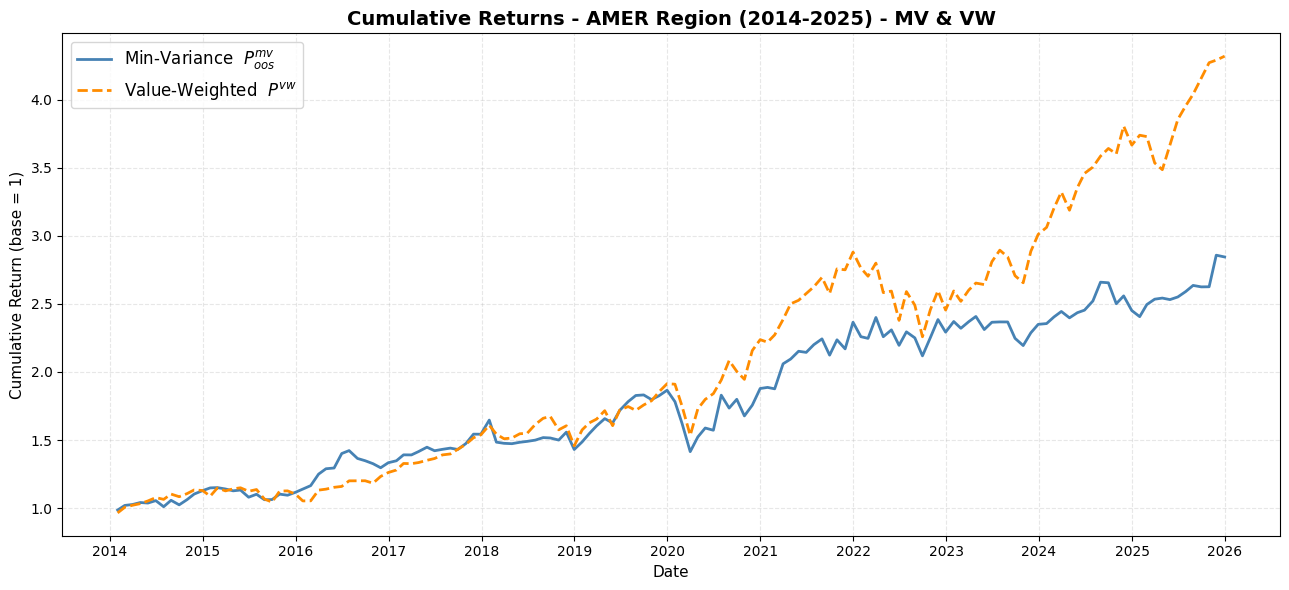

,MV_Return,VW_Return
Date,,
2014-01-31,-0.014578,-0.035396
2014-02-28,0.034427,0.042489
2014-03-31,0.006827,0.015217
2014-04-30,0.014030,0.011418
2014-05-30,-0.003694,0.019221
...,...,...
2025-08-29,0.017336,0.021425
2025-09-30,-0.004064,0.029366
2025-10-31,0.000337,0.027259


In [17]:
run_performance(mv_ret, vw_ret, data["rf"])

In [18]:
sigmas = precompute_sigmas(invest_sets, ret_windows)

  Pre-computing covariance matrices... done (12 years).


In [19]:
ci = compute_carbon_intensity(data["co2"], data["revenue"])

In [20]:
metrics_mv = compute_portfolio_carbon_metrics(
    weights_mv, ci, data["co2"], data["mv_y"], label="MV")

  MV carbon metrics computed for 12 years.


In [21]:
weights_vw = _build_vw_weights(invest_sets, data["mv_y"])

In [22]:
metrics_vw = compute_portfolio_carbon_metrics(
    weights_vw, ci, data["co2"], data["mv_y"], label="VW")

  VW carbon metrics computed for 12 years.


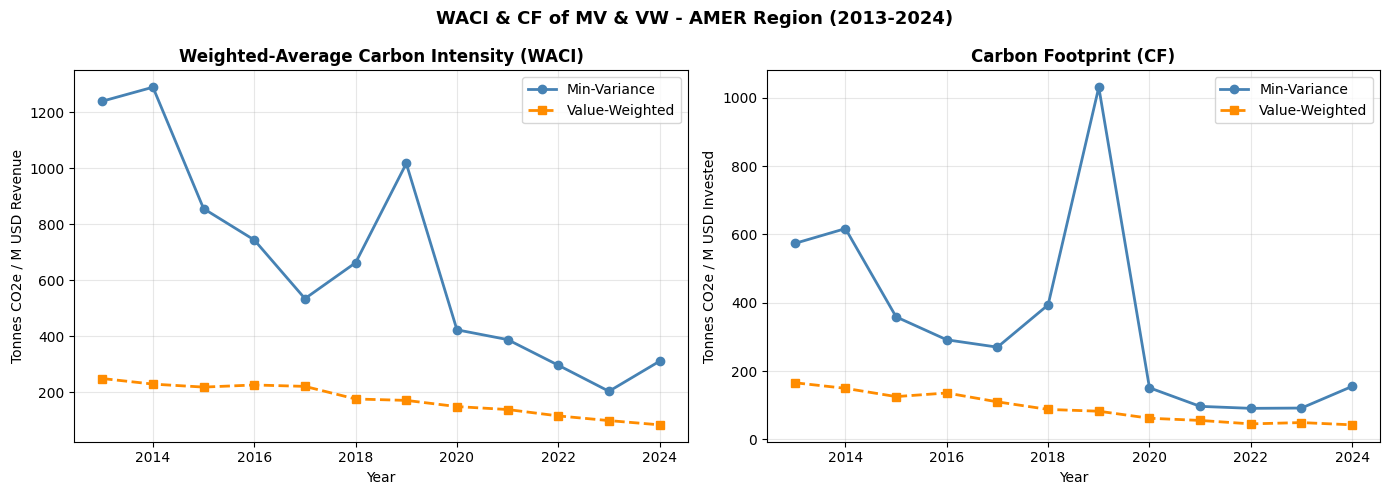

In [23]:
plot_carbon_metrics(metrics_mv, metrics_vw)

In [24]:
last_year = max(weights_mv.keys())

In [25]:
print(f"\nTop-10 carbon contributors ({last_year}):")
top10 = top_carbon_contributors(weights_mv, ci, data["static"], last_year)
display(top10)


Top-10 carbon contributors (2024):


,ISIN,Name,Weight,CI,Contribution
0,US1258961002,CMS ENERGY,0.107194,2155.431386,231.049600
1,US3379321074,FIRSTENERGY,0.023239,1089.256721,25.313066
2,US8425871071,SOUTHERN,0.005138,3138.363046,16.123575
3,US03940R1077,ARCH RESOURCES A DEAD - DELIST.14/01/25,0.009394,1573.505099,14.781781
4,US1270971039,COTERRA ENERGY,0.052081,207.131773,10.787590
5,CA8029121057,SAPUTO,0.098081,39.702441,3.894046
6,US4404521001,HORMEL FOODS,0.075118,51.527823,3.870648
7,US9291601097,VULCAN MATERIALS,0.007280,118.387026,0.861809
8,US4278661081,HERSHEY,0.049230,17.105610,0.842106
9,US69331C1080,PG&E,0.005155,140.137711,0.722352


In [26]:
weights_mvc = run_mv_carbon(
    invest_sets, ret_windows, weights_mv,
    data["co2"], data["mv_y"], sigmas, reduction=0.5)

MV WITH CARBON CONSTRAINT  (CF <= 50% x CF_mv)
  2013:  357 firms | CF_mv=573.7 | target=286.8 | achieved=286.8 | vol=6.95%
  2014:  365 firms | CF_mv=617.1 | target=308.6 | achieved=308.6 | vol=7.41%
  2015:  381 firms | CF_mv=358.6 | target=179.3 | achieved=179.3 | vol=7.64%
  2016:  399 firms | CF_mv=291.4 | target=145.7 | achieved=145.7 | vol=8.18%
  2017:  417 firms | CF_mv=269.9 | target=134.9 | achieved=134.9 | vol=7.93%
  2018:  454 firms | CF_mv=393.7 | target=196.8 | achieved=196.8 | vol=7.32%
  2019:  519 firms | CF_mv=1031.2 | target=515.6 | achieved=515.6 | vol=5.53%
  2020:  543 firms | CF_mv=150.9 | target=75.5 | achieved=75.5 | vol=7.07%
  2021:  568 firms | CF_mv=96.5 | target=48.3 | achieved=48.3 | vol=7.14%
  2022:  579 firms | CF_mv=90.7 | target=45.3 | achieved=45.3 | vol=8.12%
  2023:  579 firms | CF_mv=91.6 | target=45.8 | achieved=45.8 | vol=7.92%
  2024:  576 firms | CF_mv=155.0 | target=77.5 | achieved=77.5 | vol=8.26%
  done for 12 years.



In [27]:
mvc_ret = compute_mv_returns(weights_mvc, data["returns_m"])

  MV : 144 months  (2014-01-31 -> 2025-12-31)


In [28]:
metrics_mvc = compute_portfolio_carbon_metrics(
    weights_mvc, ci, data["co2"], data["mv_y"], label="MV(0.5)")

  MV(0.5) carbon metrics computed for 12 years.


SECTION 3.2 - MV vs MV(0.5) COMPARISON

Metric              MV  $P^{mv}_{oos}$MV carbon  $P^{mv}_{oos}(0.5)$
--------------------------------------------------------
  Ann. avg return                9.69%             9.83%
  Ann. volatility               13.84%            13.00%
  Sharpe ratio                  0.6097            0.6594
  Min monthly                  -12.75%           -10.81%
  Max monthly                   16.39%            11.02%



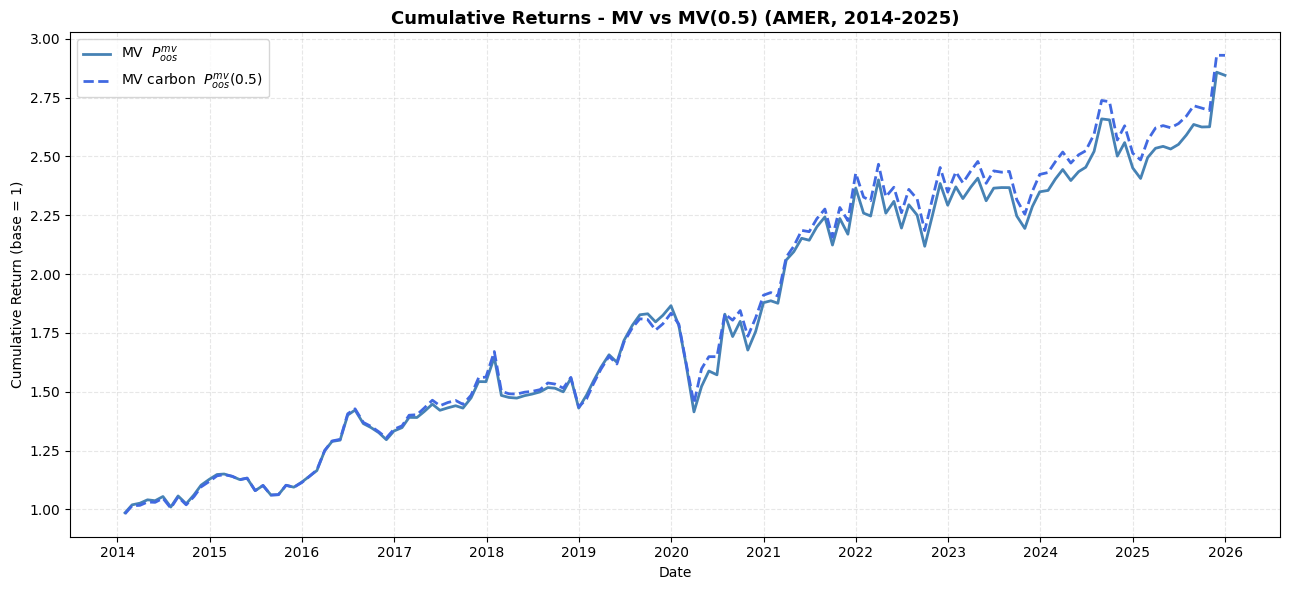

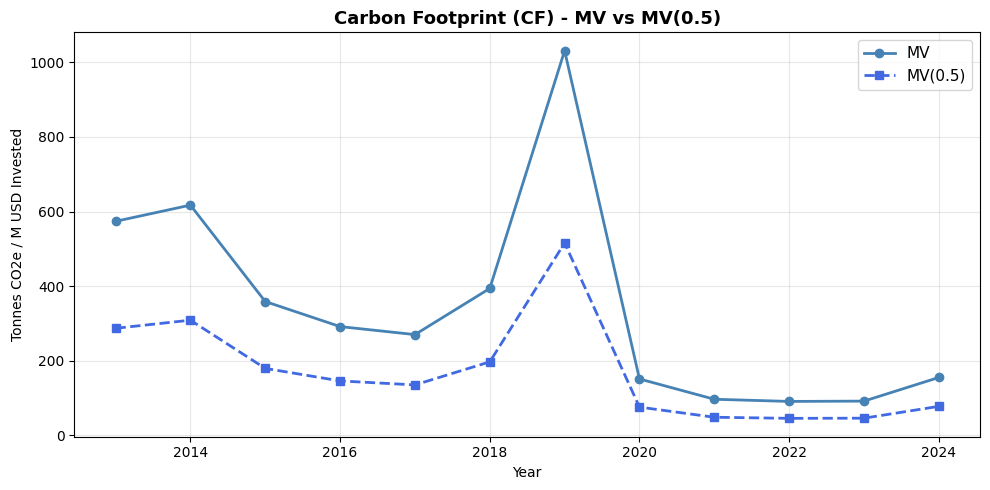

In [29]:
compare_mv_carbon_32(mv_ret, mvc_ret, data["rf"], metrics_mv, metrics_mvc)

In [30]:
weights_tec = run_te_carbon(
    invest_sets, ret_windows, data["mv_y"],
    data["co2"], data["mv_y"], sigmas, reduction=0.5, label="VW(0.5)")

TRACKING-ERROR MIN WITH CARBON CONSTRAINT  [VW(0.5)]
  2013: CF_vw=165.7 | target=82.8 | achieved=82.8 | TE=0.0000%
  2014: CF_vw=149.3 | target=74.7 | achieved=74.7 | TE=0.0261%
  2015: CF_vw=125.1 | target=62.6 | achieved=62.6 | TE=0.0232%
  2016: CF_vw=135.7 | target=67.8 | achieved=67.8 | TE=0.0246%
  2017: CF_vw=109.7 | target=54.8 | achieved=54.8 | TE=0.0248%
  2018: CF_vw=87.5 | target=43.8 | achieved=43.8 | TE=0.0000%
  2019: CF_vw=82.3 | target=41.1 | achieved=41.1 | TE=0.0000%
  2020: CF_vw=61.7 | target=30.9 | achieved=30.9 | TE=0.0000%
  2021: CF_vw=55.3 | target=27.6 | achieved=27.6 | TE=0.0000%
  2022: CF_vw=45.2 | target=22.6 | achieved=22.6 | TE=0.0000%
  2023: CF_vw=49.0 | target=24.5 | achieved=24.5 | TE=0.0068%
  2024: CF_vw=42.4 | target=21.2 | achieved=21.2 | TE=0.0000%
  done for 12 years.



In [31]:
tec_ret = compute_mv_returns(weights_tec, data["returns_m"])

  MV : 144 months  (2014-01-31 -> 2025-12-31)


In [32]:
metrics_tec = compute_portfolio_carbon_metrics(
    weights_tec, ci, data["co2"], data["mv_y"], label="VW(0.5)")

  VW(0.5) carbon metrics computed for 12 years.


SECTION 3.3 - VW vs VW(0.5) COMPARISON

Metric              VW  $P^{vw}_{oos}$TE carbon  $P^{vw}_{oos}(0.5)$
--------------------------------------------------------
  Ann. avg return               13.27%            13.44%
  Ann. volatility               14.25%            15.13%
  Sharpe ratio                  0.8428            0.8054
  Min monthly                  -12.23%           -14.90%
  Max monthly                   12.70%            13.39%



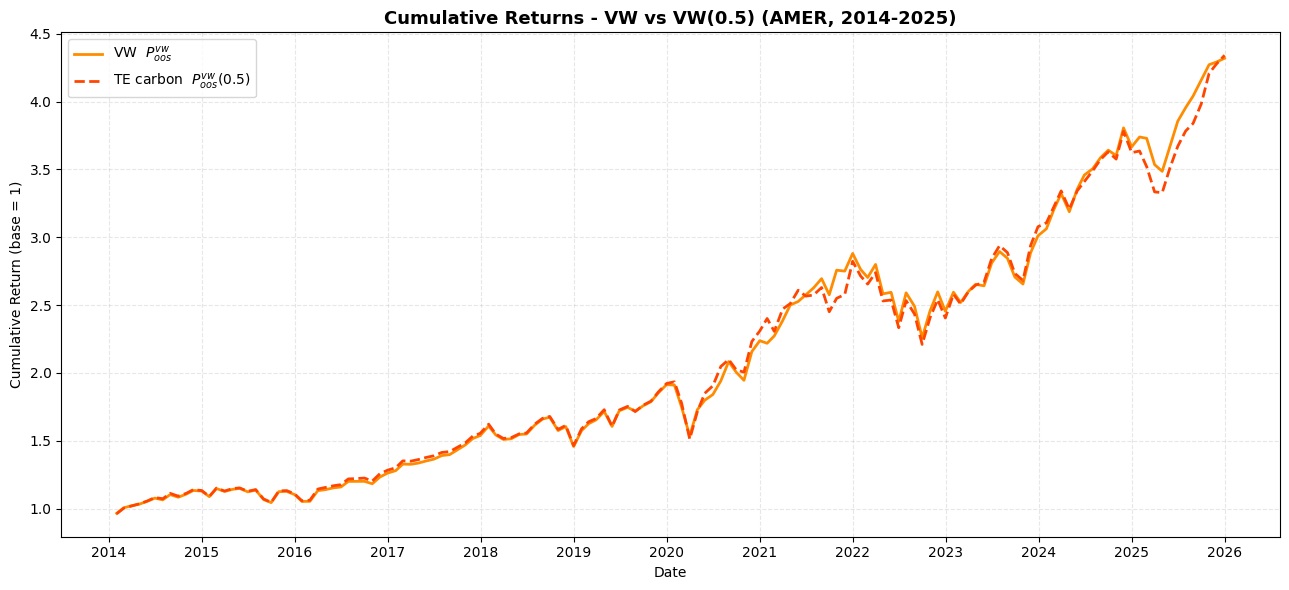

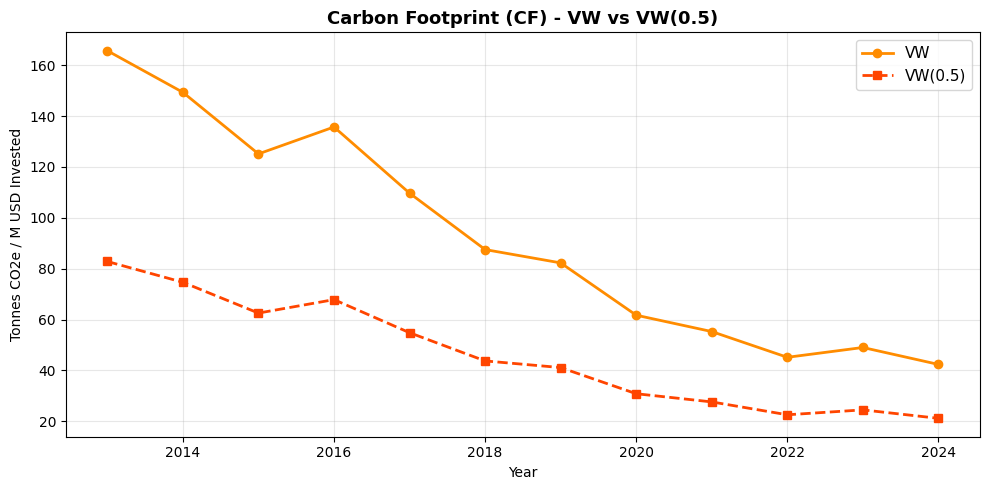

In [33]:
compare_vw_carbon_33(vw_ret, tec_ret, data["rf"], metrics_vw, metrics_tec)

SECTION 3.4 - PORTFOLIO COMPARISON

Metric              MV  $P^{mv}_{oos}$MV carbon  $P^{mv}_{oos}(0.5)$VW  $P^{vw}_{oos}$TE carbon  $P^{vw}_{oos}(0.5)$
--------------------------------------------------------------------------------------------
  Ann. avg return                9.69%             9.83%            13.27%            13.44%
  Ann. volatility               13.84%            13.00%            14.25%            15.13%
  Sharpe ratio                  0.6097            0.6594            0.8428            0.8054
  Min monthly                  -12.75%           -10.81%           -12.23%           -14.90%
  Max monthly                   16.39%            11.02%            12.70%            13.39%



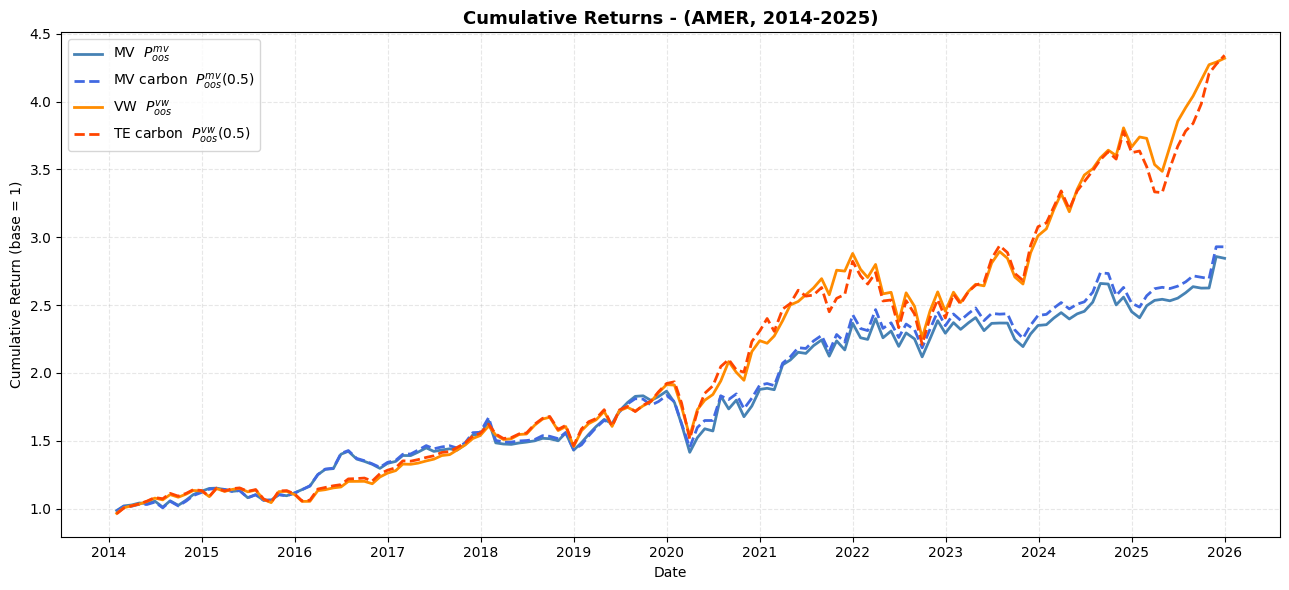

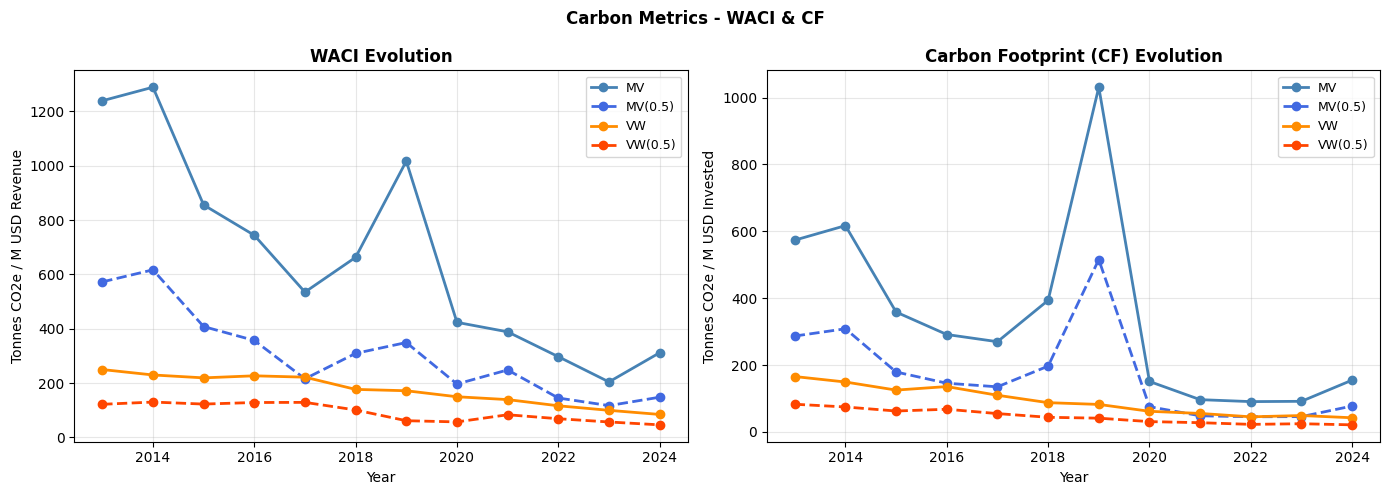

In [34]:
compare_portfolios_34(
    mv_ret, mvc_ret, vw_ret, tec_ret, data["rf"],
    metrics_mv, metrics_mvc, metrics_vw, metrics_tec)

In [35]:
weights_nz = run_net_zero(
    invest_sets, ret_windows, data["mv_y"],
    data["co2"], data["mv_y"], sigmas, theta=0.10, Y0=2013)

NET ZERO PORTFOLIO  (theta=10%/yr, base=2013)
  CF_vw(2013) = 165.6688  (reference level)
  2013: target=149.1019 | achieved=149.1019 | TE=0.0187%
  2014: target=134.1918 | achieved=134.1918 | TE=0.0212%
  2015: target=120.7726 | achieved=120.7726 | TE=0.0099%
  2016: target=108.6953 | achieved=108.6953 | TE=0.0189%
  2017: target=97.8258 | achieved=97.8258 | TE=0.0195%
  2018: target=88.0432 | achieved=87.5179 | TE=0.0000%
  2019: target=79.2389 | achieved=79.2389 | TE=0.0090%
  2020: target=71.3150 | achieved=61.7277 | TE=0.0000%
  2021: target=64.1835 | achieved=55.2910 | TE=0.0000%
  2022: target=57.7651 | achieved=45.1780 | TE=0.0000%
  2023: target=51.9886 | achieved=49.0355 | TE=0.0000%
  2024: target=46.7898 | achieved=42.3802 | TE=0.0000%
  done for 12 years.



In [36]:
nz_ret = compute_mv_returns(weights_nz, data["returns_m"])

  MV : 144 months  (2014-01-31 -> 2025-12-31)


In [37]:
metrics_nz = compute_portfolio_carbon_metrics(
    weights_nz, ci, data["co2"], data["mv_y"], label="VW(NZ)")

  VW(NZ) carbon metrics computed for 12 years.


SECTION 4.2 - NET ZERO COMPARISON

Metric              VW  $P^{vw}_{oos}$TE carbon  $P^{vw}_{oos}(0.5)$Net Zero  $P^{vw}_{oos}(NZ)$
--------------------------------------------------------------------------
  Ann. avg return               13.27%            13.44%            13.04%
  Ann. volatility               14.25%            15.13%            14.40%
  Sharpe ratio                  0.8428            0.8054            0.8185
  Min monthly                  -12.23%           -14.90%           -12.93%
  Max monthly                   12.70%            13.39%            12.67%



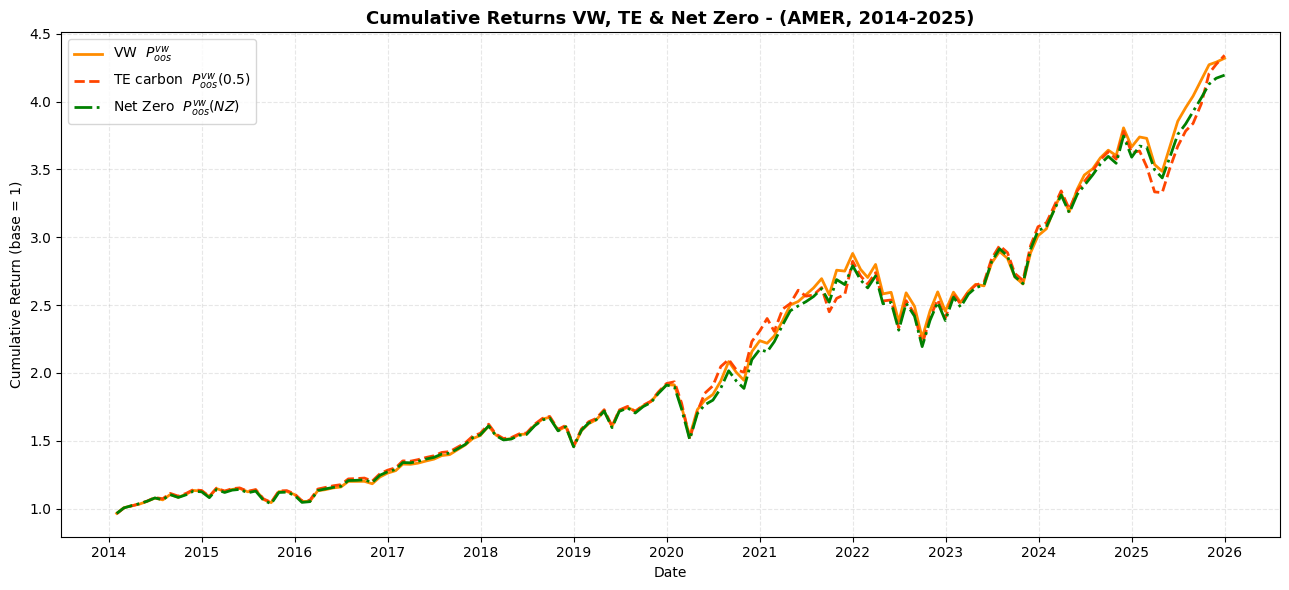

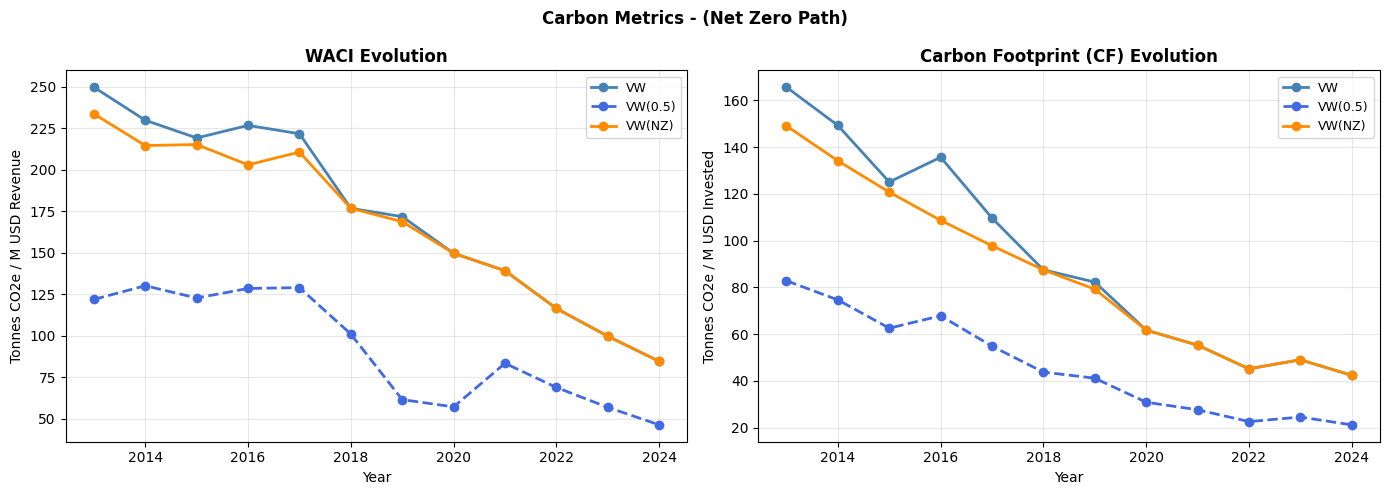

In [38]:
compare_portfolios_42(
    vw_ret, tec_ret, nz_ret, data["rf"],
    metrics_vw, metrics_tec, metrics_nz)

ALL PORTFOLIOS COMPARISON

Metric              MV  $P^{mv}_{oos}$MV carbon  $P^{mv}_{oos}(0.5)$VW  $P^{vw}_{oos}$TE carbon  $P^{vw}_{oos}(0.5)$Net Zero  $P^{vw}_{oos}(NZ)$
--------------------------------------------------------------------------------------------------------------
  Ann. avg return                9.69%             9.83%            13.27%            13.44%            13.04%
  Ann. volatility               13.84%            13.00%            14.25%            15.13%            14.40%
  Sharpe ratio                  0.6097            0.6594            0.8428            0.8054            0.8185
  Min monthly                  -12.75%           -10.81%           -12.23%           -14.90%           -12.93%
  Max monthly                   16.39%            11.02%            12.70%            13.39%            12.67%



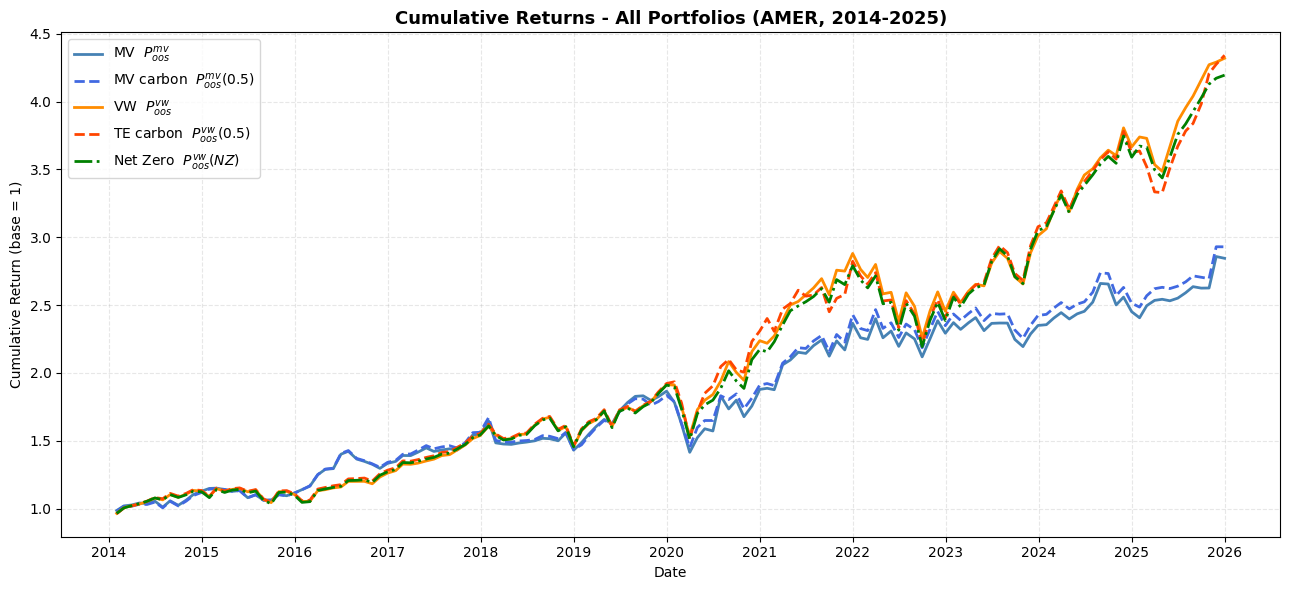

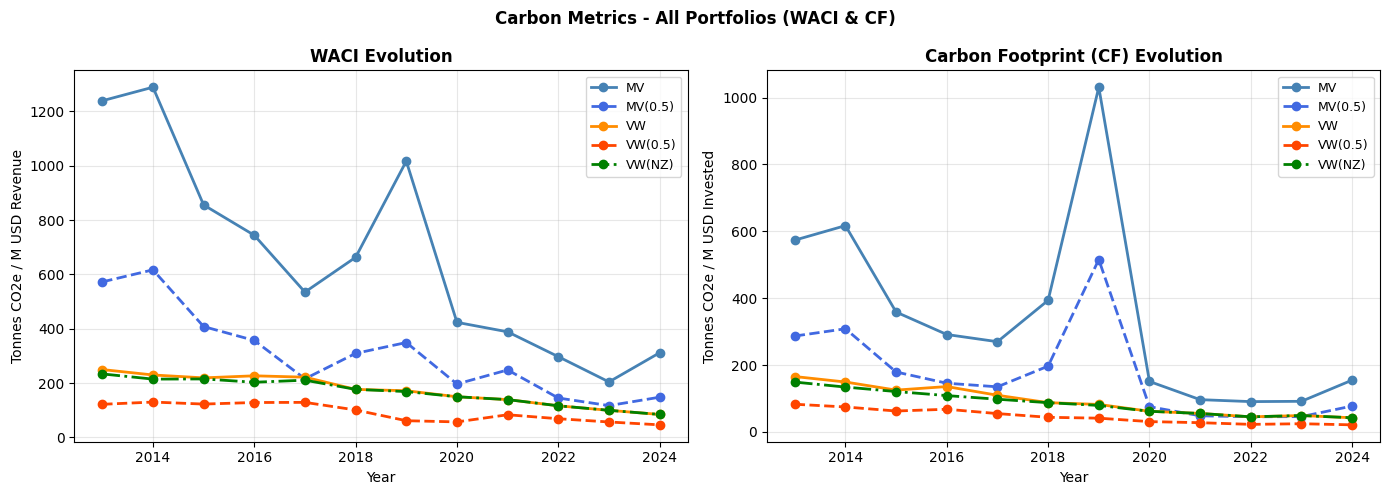

In [39]:
compare_all_portfolios(
    mv_ret, mvc_ret, vw_ret, tec_ret, nz_ret, data["rf"],
    metrics_mv, metrics_mvc, metrics_vw, metrics_tec, metrics_nz)